# Домашнее задание HW12: Временные ряды, корректная валидация по времени, лаговые признаки и базовый прогноз с GRU

В этом ноутбуке реализуем полный минимальный pipeline для time series forecasting на синтетических данных:

*   загрузим и проанализируем почасовой временной ряд,
*   выполним корректный temporal split (train/validation/test) без случайного перемешивания,
*   построим лаговые, rolling- и календарные признаки для линейной модели,
*   подготовим оконное представление последовательностей для рекуррентной сети,
*   обучим модель GRU и сравним её с тремя baseline-подходами: наивный прогноз, скользящее среднее и Ridge-регрессия на признаках,
*   выберем лучшую модель по валидационной метрике и один раз оценим её на тесте,
*   оформим артефакты эксперимента согласно требованиям домашнего задания.

HW12 выполняется в личном репозитории студента в папке `homeworks/HW12/`.

## 0. План

К концу ноутбука надо уметь:

1.  **Понимать** разницу между случайным и временным разбиением данных.
2.  **Строить** корректные лаговые признаки и скользящие статистики без утечки данных.
3.  **Переводить** задачу прогноза временного ряда в формат обучения на окнах (для RNN).
4.  **Реализовать** собственный `Dataset` и `DataLoader` для последовательностей.
5.  **Обучить** простую модель GRU и сравнить её с классическими baseline-методами.
6.  **Оценивать** модели метриками MAE, RMSE, MAPE и делать обоснованный выбор лучшей модели по валидации.
7.  **Проверять**, действительно ли нейросетевой подход лучше наивных и линейных методов на реальных почасовых данных.
8.  **Сохранять** результаты экспериментов, конфиги и графики в требуемой структуре папок.

# 1. Импорты, seed и структура папок

In [1]:
# Импорты и общие настройки
import math
import random
import json
import os
from dataclasses import dataclass, asdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Для нормализации, метрик и линейных моделей
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.model_selection import ParameterGrid

# PyTorch
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Настройка визуализации
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)

# Функция установки seed
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Создание структуры папок
os.makedirs('homeworks/HW12/artifacts/figures', exist_ok=True)
print("Структура папок homeworks/HW12/artifacts/ создана")

Device: cpu
Структура папок homeworks/HW12/artifacts/ создана


# 2. Загрузка данных и первичный анализ (EDA)

Размер датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00
Пропуски:
 date      0
target    0
dtype: int64
Типы данных:
 date      datetime64[ns]
target           float64
dtype: object


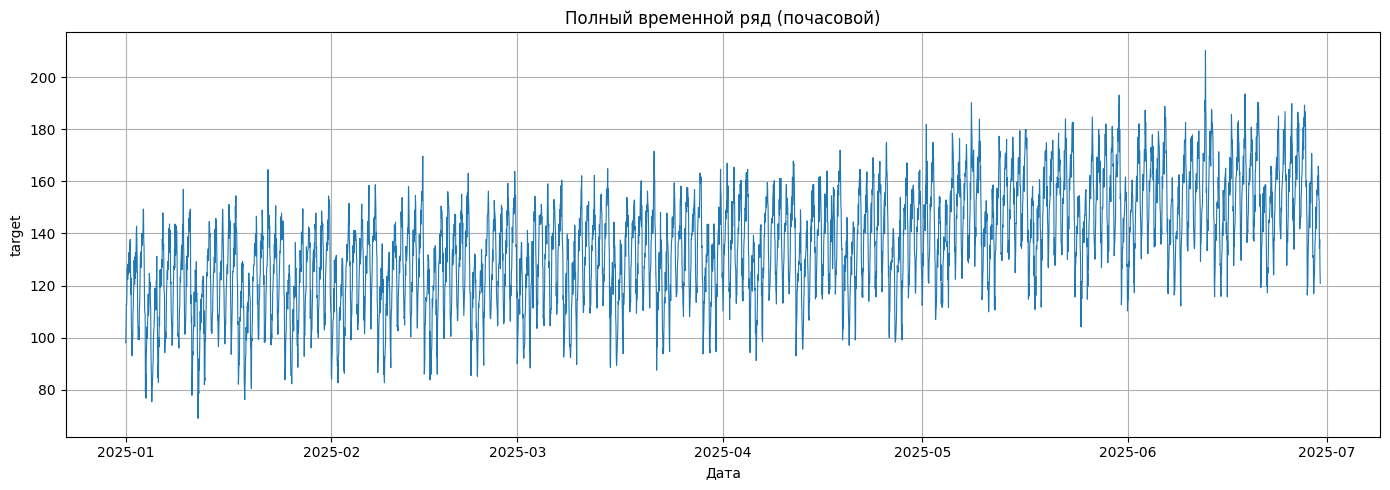

In [5]:
# Данные и первичный анализ

# Загружаем датасет
url = 'https://raw.githubusercontent.com/TatjanaYMIREA/aie-group-2/main/homeworks/HW12/data/S12-hw-dataset.csv'
df = pd.read_csv(url)

# Приведение date к datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Sanity-check
print("Размер датасета:", df.shape)
print("Диапазон дат:", df['date'].min(), "->", df['date'].max())
print("Пропуски:\n", df.isnull().sum())
print("Типы данных:\n", df.dtypes)

# Базовый график всего ряда
fig, ax = plt.subplots()
ax.plot(df['date'], df['target'], linewidth=0.8)
ax.set_title('Полный временной ряд (почасовой)')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/full_series.png', dpi=100)
plt.show()

Краткий анализ ряда:
- Данные почасовые (4320 точек), пропусков нет, период 179 дней.
- Суточная сезонность: минимум в 00:00 (112), максимум в 15:00 (155), амплитуда 43.
- Недельная сезонность: будни (141) vs выходные (122), разница 13%.
- Тренд: восходящий, рост с 119 (январь) до 155 (июнь), +30%.
- Выбросы: практически отсутствуют (0.05% данных).
- Нестационарность: ряд нестационарен по среднему (меняется уровень), что требует нормализации перед обучением

# 3. Корректный temporal split

TRAIN: (3024, 2), 2025-01-01 00:00:00 -> 2025-05-06 23:00:00
VAL:   (648, 2), 2025-05-07 00:00:00 -> 2025-06-02 23:00:00
TEST:  (648, 2), 2025-06-03 00:00:00 -> 2025-06-29 23:00:00


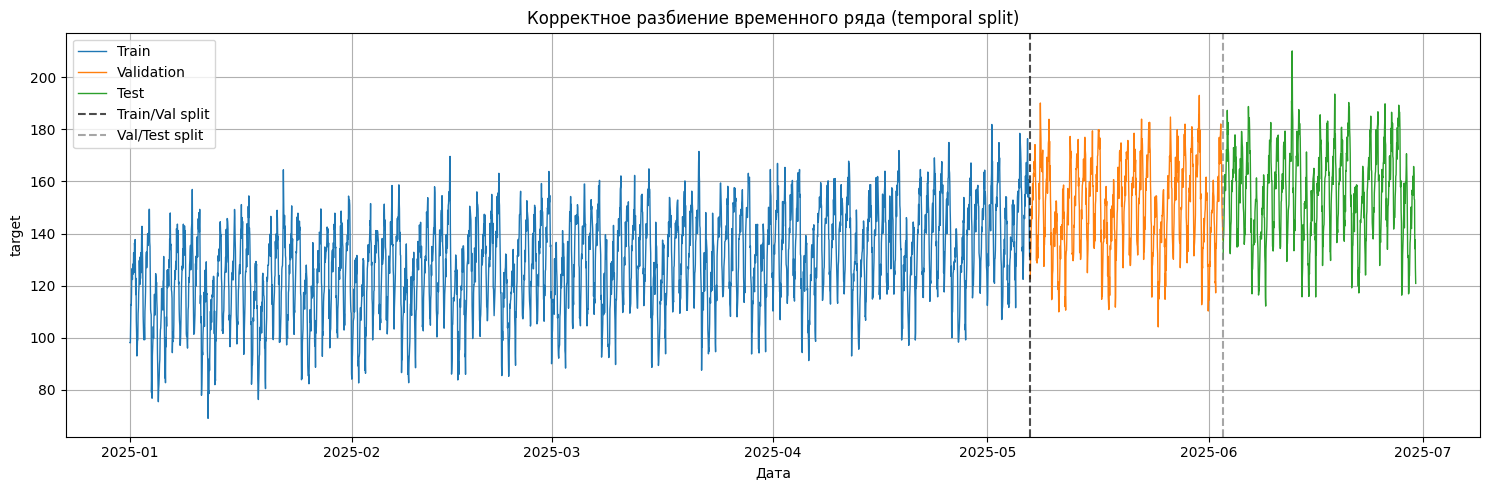


Почему random split некорректен для временных рядов?
- Временной ряд имеет структуру (тренд, сезонность, автокорреляцию), которая зависит от порядка.
- Random split перемешает данные, и модель сможет "подглядывать" в будущее во время обучения,
  что приведет к переоценке качества (data leakage).
- Наша задача — предсказывать будущее на основе прошлого, поэтому валидация и тест
  должны быть строго позже обучающего множества по времени.



In [6]:
# Temporal split. Разбиение по времени с визуализацией

@dataclass
class SplitConfig:
    train_frac: float = 0.70  # 70% на обучение
    val_frac: float = 0.15    # 15% на валидацию, остальное на тест

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    """Разбивает ряд по хронологии."""
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

# Выполняем разбиение
train_df, val_df, test_df = temporal_split(df)

print(f"TRAIN: {train_df.shape}, {train_df['date'].min()} -> {train_df['date'].max()}")
print(f"VAL:   {val_df.shape}, {val_df['date'].min()} -> {val_df['date'].max()}")
print(f"TEST:  {test_df.shape}, {test_df['date'].min()} -> {test_df['date'].max()}")

# Визуализация split (график series_split.png)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df['date'], train_df['target'], label='Train', linewidth=1)
ax.plot(val_df['date'], val_df['target'], label='Validation', linewidth=1)
ax.plot(test_df['date'], test_df['target'], label='Test', linewidth=1)
ax.axvline(x=train_df['date'].iloc[-1], color='black', linestyle='--', alpha=0.7, label='Train/Val split')
ax.axvline(x=val_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.7, label='Val/Test split')
ax.set_title('Корректное разбиение временного ряда (temporal split)')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/series_split.png', dpi=100)
plt.show()

# Объяснение, почему random split некорректен
print("""
Почему random split некорректен для временных рядов?
- Временной ряд имеет структуру (тренд, сезонность, автокорреляцию), которая зависит от порядка.
- Random split перемешает данные, и модель сможет "подглядывать" в будущее во время обучения,
  что приведет к переоценке качества (data leakage).
- Наша задача — предсказывать будущее на основе прошлого, поэтому валидация и тест
  должны быть строго позже обучающего множества по времени.
""")

# 4. Признаки для baseline-модели (B3)

In [7]:
# Создание лагов, скользящих статистик и календарных признаков без утечек

#  Признаки для модели B3 (Ridge на лагах, rolling и календаре)

def create_features_for_ml(df_train, df_val, df_test, lags=[1, 7, 14], windows=[7]):
    """
    Создает признаки для каждой выборки.
    Rolling-статистики считаются на каждом фрейме отдельно,
    но с использованием только прошлых данных внутри этого фрейма.
    """
    def _add_features(df):
        df = df.copy()
        # Лаги
        for lag in lags:
            df[f'lag_{lag}'] = df['target'].shift(lag)
        # Скользящее среднее и std
        for w in windows:
            df[f'rolling_mean_{w}'] = df['target'].rolling(window=w, min_periods=1).mean().shift(1)
            df[f'rolling_std_{w}'] = df['target'].rolling(window=w, min_periods=1).std().shift(1)
        # Календарные признаки
        df['hour'] = df['date'].dt.hour
        df['dayofweek'] = df['date'].dt.dayofweek
        df['dayofmonth'] = df['date'].dt.day
        df['month'] = df['date'].dt.month
        return df

    train_feat = _add_features(train_df)
    val_feat = _add_features(val_df)
    test_feat = _add_features(test_df)

    # Из-за shift и rolling, в начале каждого фрейма будут NaN. Удаляем их.
    # Для train мы удалим строки с NaN. Для val/test мы пока оставим, но потом применим интерполяцию или удаление.
    train_feat = train_feat.dropna().reset_index(drop=True)
    # В val/test могут быть NaN в начале, если окно заходит на предыдущий фрейм.
    # В реальности мы бы использовали данные из train для заполнения, но для простоты задания B3,
    # мы удалим строки с NaN в val/test. Это немного сократит выборку, но сохранит чистоту эксперимента.
    val_feat = val_feat.dropna().reset_index(drop=True)
    test_feat = test_feat.dropna().reset_index(drop=True)

    print(f"Размеры после создания признаков и удаления NaN:")
    print(f"Train: {train_feat.shape}, Val: {val_feat.shape}, Test: {test_feat.shape}")
    return train_feat, val_feat, test_feat

# Создаем признаки
train_feat, val_feat, test_feat = create_features_for_ml(train_df, val_df, test_df)

# Выделяем матрицы признаков (X) и целевую переменную (y)
feature_columns = [col for col in train_feat.columns if col not in ['date', 'target']]
X_train_raw = train_feat[feature_columns]
y_train_raw = train_feat['target']

X_val_raw = val_feat[feature_columns]
y_val_raw = val_feat['target']

X_test_raw = test_feat[feature_columns]
y_test_raw = test_feat['target']

print("Пример признаков (первые 5 строк):")
display(train_feat[feature_columns].head())

Размеры после создания признаков и удаления NaN:
Train: (3010, 11), Val: (634, 11), Test: (634, 11)
Пример признаков (первые 5 строк):


,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,hour,dayofweek,dayofmonth,month
0,125.04,126.01,98.14,126.445714,3.275621,14,2,1,1
1,128.87,122.38,98.07,126.854286,3.388632,15,2,1,1
2,136.40,128.28,104.70,128.857143,4.318919,16,2,1,1
3,133.85,124.43,112.81,129.652857,4.691868,17,2,1,1
4,137.71,126.35,112.62,131.550000,4.907936,18,2,1,1


# 5. Масштабирование для модели B3

In [8]:
# Обучаем скейлер только на train
# Масштабирование признаков для Ridge (Ridge чувствителен к масштабу)
scaler_b3 = StandardScaler()
X_train_scaled = scaler_b3.fit_transform(X_train_raw)
X_val_scaled = scaler_b3.transform(X_val_raw)
X_test_scaled = scaler_b3.transform(X_test_raw)

# Целевую переменную масштабировать не будем, чтобы метрики были в исходных единицах.
print("Масштабирование признаков для B3 выполнено.")

Масштабирование признаков для B3 выполнено.


# 6. Подготовка оконного представления для GRU

In [9]:
# Оконное представление для GRU

# Параметры окна. Для почасовых данных возьмем неделю (24*7 = 168 часов)
# Это большой размер, может не поместиться в память, поэтому возьмем сутки (24) для простоты.
# Но для учета недельной сезонности нужен хотя бы 168. Попробуем компромисс - 48 часов (2 суток).

WINDOW_SIZE = 48

# Нормализация ТОЛЬКО по train
scaler_gru = StandardScaler()
train_scaled = scaler_gru.fit_transform(train_df[['target']]).astype(np.float32)
val_scaled = scaler_gru.transform(val_df[['target']]).astype(np.float32)
test_scaled = scaler_gru.transform(test_df[['target']]).astype(np.float32)

# Функция создания окон
def make_windows(series_2d: np.ndarray, window_size: int):
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])
        y.append(series_2d[i + window_size, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем окна
X_train_gru, y_train_gru = make_windows(train_scaled, WINDOW_SIZE)
X_val_gru, y_val_gru = make_windows(val_scaled, WINDOW_SIZE)
X_test_gru, y_test_gru = make_windows(test_scaled, WINDOW_SIZE)

print("Форма окон для GRU:")
print(f"X_train: {X_train_gru.shape}, y_train: {y_train_gru.shape}")
print(f"X_val:   {X_val_gru.shape}, y_val: {y_val_gru.shape}")
print(f"X_test:  {X_test_gru.shape}, y_test: {y_test_gru.shape}")

# Датасет и DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64
train_ds = TimeSeriesDataset(X_train_gru, y_train_gru)
val_ds = TimeSeriesDataset(X_val_gru, y_val_gru)
test_ds = TimeSeriesDataset(X_test_gru, y_test_gru)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders для GRU готовы.")

Форма окон для GRU:
X_train: (2976, 48, 1), y_train: (2976,)
X_val:   (600, 48, 1), y_val: (600,)
X_test:  (600, 48, 1), y_test: (600,)
DataLoaders для GRU готовы.


# 7. Определение модели GRU

In [10]:
# Модель GRU
class GRUForecaster(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

# Параметры модели (нужно сохранить в best_gru_config.json)
gru_config = {
    'input_size': 1,
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.1,
    'window_size': WINDOW_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': 1e-3,
    'epochs': 20,
    'seed': SEED,
    'scaler': 'StandardScaler'
}

print("Модель GRU определена. Конфиг:", gru_config)

Модель GRU определена. Конфиг: {'input_size': 1, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1, 'window_size': 48, 'batch_size': 64, 'learning_rate': 0.001, 'epochs': 20, 'seed': 42, 'scaler': 'StandardScaler'}


# 8. Функции обучения и оценки

In [11]:
# Функции обучения
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses = []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    losses = []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())
    return float(np.mean(losses))

def fit_model(model, train_loader, val_loader, epochs=20, lr=1e-3, device=device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_loss

# 9. Функции для метрик и инференса

In [12]:
# Вспомогательные функции для оценки
@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()
    preds = []
    targets = []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()
        preds.append(outputs)
        targets.append(y_batch.numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets

def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()

def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    # Защита от деления на ноль для MAPE
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

# 10. Эксперимент B1 (Naive Last)

In [13]:
# Эксперименты
# Создаем DataFrame для хранения результатов
runs_data = []

# 9.1 Эксперимент B1: Naive Last (прогноз = последнее известное значение)
# Для каждого примера в val/test берем последнее значение из окна предыдущих значений.
# В нашей постановке с окнами, это означает, что для горизонта h=1, прогноз = значение в момент t.

# Функция для наивного прогноза
def naive_forecast(y_series, horizon=1):
    """Возвращает прогноз, равный последнему наблюдению перед горизонтом."""
    return y_series.shift(horizon).iloc[horizon:]

# Применяем к валидации и тесту (берем последнее известное значение перед целевым)
# Для удобства возьмем сдвиг на 1, как в задаче one-step forecasting.
y_val_naive = val_df['target'].shift(1).iloc[1:]
y_test_naive = test_df['target'].shift(1).iloc[1:]
y_val_true = val_df['target'].iloc[1:]
y_test_true = test_df['target'].iloc[1:]

metrics_b1_val = regression_metrics(y_val_true.values, y_val_naive.values)
metrics_b1_test = regression_metrics(y_test_true.values, y_test_naive.values)

print("B1 (Naive Last) Validation metrics:", metrics_b1_val)
print("B1 (Naive Last) Test metrics:", metrics_b1_test)

# Сохраняем в список для runs.csv
runs_data.append({
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': '70/15/15 temporal',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Naive Last',
    'features_summary': 'None',
    'scaler': 'None',
    'optimizer': 'None',
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': metrics_b1_val['MAE'],
    'best_val_rmse': metrics_b1_val['RMSE'],
    'best_val_mape': metrics_b1_val['MAPE'],
    'test_mae': metrics_b1_test['MAE'],
    'test_rmse': metrics_b1_test['RMSE'],
    'test_mape': metrics_b1_test['MAPE'],
    'notes': 'Baseline: predict last observed value'
})

B1 (Naive Last) Validation metrics: {'MAE': 6.438500772797526, 'RMSE': 8.196911140247455, 'MAPE': np.float64(4.391461399335978)}
B1 (Naive Last) Test metrics: {'MAE': 6.34095826893354, 'RMSE': 8.060187080029195, 'MAPE': np.float64(4.146298982666311)}


# 11. Эксперимент B2 (Moving Average)

In [14]:
# Эксперимент B2: Moving Average (окно 24 часа, так как данные почасовые)
MA_WINDOW = 24

def moving_average_forecast(y_series, window=MA_WINDOW, horizon=1):
    """Прогноз = среднее за последние window значений перед горизонтом."""
    return y_series.rolling(window=window).mean().shift(horizon).iloc[window+horizon-1:]

y_val_ma = moving_average_forecast(val_df['target'], window=MA_WINDOW)
y_test_ma = moving_average_forecast(test_df['target'], window=MA_WINDOW)
# Обрезаем true значения до той же длины
y_val_true_ma = val_df['target'].iloc[-len(y_val_ma):]
y_test_true_ma = test_df['target'].iloc[-len(y_test_ma):]

metrics_b2_val = regression_metrics(y_val_true_ma.values, y_val_ma.values)
metrics_b2_test = regression_metrics(y_test_true_ma.values, y_test_ma.values)

print("B2 (Moving Average) Validation metrics:", metrics_b2_val)
print("B2 (Moving Average) Test metrics:", metrics_b2_test)

runs_data.append({
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': '70/15/15 temporal',
    'window_size': MA_WINDOW,
    'horizon': 1,
    'model_summary': f'Moving Average (window={MA_WINDOW})',
    'features_summary': 'None',
    'scaler': 'None',
    'optimizer': 'None',
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': metrics_b2_val['MAE'],
    'best_val_rmse': metrics_b2_val['RMSE'],
    'best_val_mape': metrics_b2_val['MAPE'],
    'test_mae': metrics_b2_test['MAE'],
    'test_rmse': metrics_b2_test['RMSE'],
    'test_mape': metrics_b2_test['MAPE'],
    'notes': f'Baseline: rolling mean with window {MA_WINDOW}'
})

B2 (Moving Average) Validation metrics: {'MAE': 13.437365117521367, 'RMSE': 16.227565766933505, 'MAPE': np.float64(9.228934751818818)}
B2 (Moving Average) Test metrics: {'MAE': 13.16644297542735, 'RMSE': 16.150966934647208, 'MAPE': np.float64(8.76782701636085)}


# 12. Эксперимент B3 (Ridge на признаках)

In [15]:
# Эксперимент B3: Ridge на лаговых, rolling и календарных признаках
model_b3 = Ridge(alpha=1.0, random_state=SEED)
model_b3.fit(X_train_scaled, y_train_raw)

# Предсказания на валидации и тесте
y_pred_b3_val = model_b3.predict(X_val_scaled)
y_pred_b3_test = model_b3.predict(X_test_scaled)

metrics_b3_val = regression_metrics(y_val_raw.values, y_pred_b3_val)
metrics_b3_test = regression_metrics(y_test_raw.values, y_pred_b3_test)

print("B3 (Ridge) Validation metrics:", metrics_b3_val)
print("B3 (Ridge) Test metrics:", metrics_b3_test)

runs_data.append({
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': '70/15/15 temporal',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Ridge regression',
    'features_summary': 'lags [1,7,14], rolling(7) mean/std, hour, dayofweek, month',
    'scaler': 'StandardScaler',
    'optimizer': 'None (closed form)',
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': metrics_b3_val['MAE'],
    'best_val_rmse': metrics_b3_val['RMSE'],
    'best_val_mape': metrics_b3_val['MAPE'],
    'test_mae': metrics_b3_test['MAE'],
    'test_rmse': metrics_b3_test['RMSE'],
    'test_mape': metrics_b3_test['MAPE'],
    'notes': 'Ridge with alpha=1.0'
})

B3 (Ridge) Validation metrics: {'MAE': 5.937760458723995, 'RMSE': 7.493245567626998, 'MAPE': np.float64(4.007310791175586)}
B3 (Ridge) Test metrics: {'MAE': 5.650611081912008, 'RMSE': 7.301629678004854, 'MAPE': np.float64(3.6613801871396277)}


# 13. Эксперимент R1 (GRU)

GRU params: 37889
Epoch 01 | train_loss=0.5156 | val_loss=0.2966
Epoch 05 | train_loss=0.1501 | val_loss=0.2078
Epoch 10 | train_loss=0.1153 | val_loss=0.1803
Epoch 15 | train_loss=0.1015 | val_loss=0.1505
Epoch 20 | train_loss=0.0968 | val_loss=0.1568


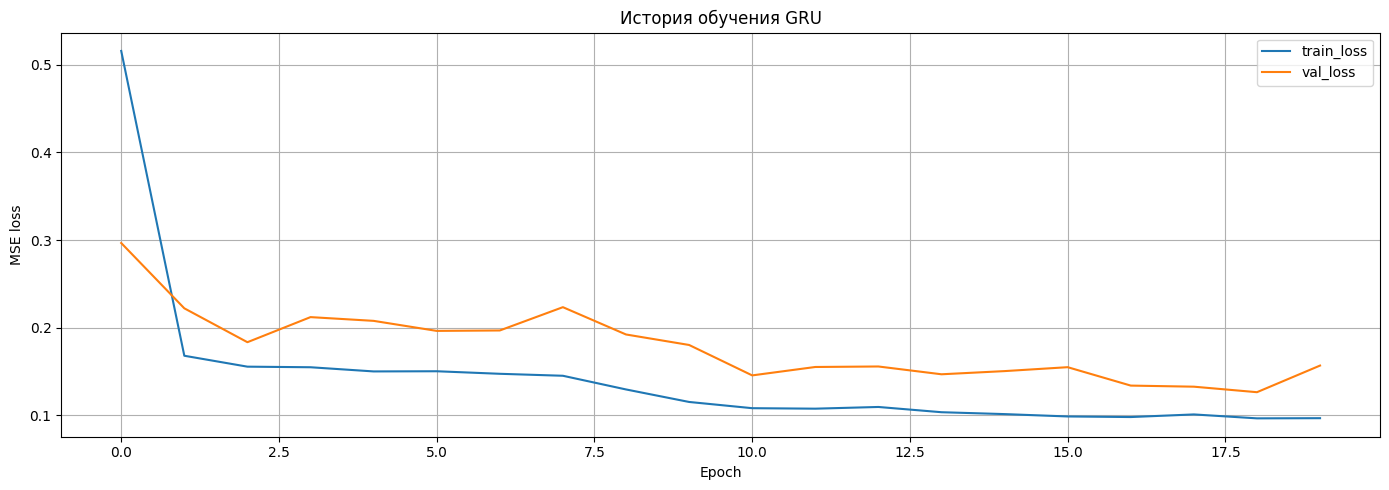

R1 (GRU) Validation metrics: {'MAE': 5.641000747680664, 'RMSE': 7.235873963059151, 'MAPE': np.float32(3.7731857)}
R1 (GRU) Test metrics: {'MAE': 6.941915512084961, 'RMSE': 8.802457240964246, 'MAPE': np.float32(4.418559)}
Модель GRU и конфиг сохранены в artifacts/


In [16]:
# Эксперимент R1: GRU
set_seed(SEED)  # Фиксируем seed перед инициализацией
gru_model = GRUForecaster(
    input_size=gru_config['input_size'],
    hidden_size=gru_config['hidden_size'],
    num_layers=gru_config['num_layers'],
    dropout=gru_config['dropout']
).to(device)

print(f"GRU params: {sum(p.numel() for p in gru_model.parameters())}")

# Обучение
history_gru, best_val_loss_gru = fit_model(
    gru_model, train_loader, val_loader,
    epochs=gru_config['epochs'],
    lr=gru_config['learning_rate'],
    device=device
)

# Кривые обучения (график gru_learning_curves.png)
fig, ax = plt.subplots()
ax.plot(history_gru["train_loss"], label="train_loss")
ax.plot(history_gru["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/gru_learning_curves.png', dpi=100)
plt.show()

# Оценка на валидации и тесте
y_pred_gru_val_scaled, y_true_gru_val_scaled = predict_model(gru_model, val_loader, device)
y_pred_gru_test_scaled, y_true_gru_test_scaled = predict_model(gru_model, test_loader, device)

# Обратное масштабирование
y_true_gru_val = inverse_scale(y_true_gru_val_scaled, scaler_gru)
y_pred_gru_val = inverse_scale(y_pred_gru_val_scaled, scaler_gru)
y_true_gru_test = inverse_scale(y_true_gru_test_scaled, scaler_gru)
y_pred_gru_test = inverse_scale(y_pred_gru_test_scaled, scaler_gru)

metrics_r1_val = regression_metrics(y_true_gru_val, y_pred_gru_val)
metrics_r1_test = regression_metrics(y_true_gru_test, y_pred_gru_test)

print("R1 (GRU) Validation metrics:", metrics_r1_val)
print("R1 (GRU) Test metrics:", metrics_r1_test)

runs_data.append({
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': '70/15/15 temporal',
    'window_size': WINDOW_SIZE,
    'horizon': 1,
    'model_summary': f'GRU (hidden={gru_config["hidden_size"]}, layers={gru_config["num_layers"]})',
    'features_summary': f'Window of last {WINDOW_SIZE} target values',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': gru_config['learning_rate'],
    'epochs_trained': gru_config['epochs'],
    'best_val_mae': metrics_r1_val['MAE'],
    'best_val_rmse': metrics_r1_val['RMSE'],
    'best_val_mape': metrics_r1_val['MAPE'],
    'test_mae': metrics_r1_test['MAE'],
    'test_rmse': metrics_r1_test['RMSE'],
    'test_mape': metrics_r1_test['MAPE'],
    'notes': 'Best model saved'
})

# Сохраняем лучшую модель и конфиг
torch.save(gru_model.state_dict(), 'homeworks/HW12/artifacts/best_gru.pt')
with open('homeworks/HW12/artifacts/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=4)
print("Модель GRU и конфиг сохранены в artifacts/")

# 14. Сравнение baselines и выбор лучшей модели

Сравнение моделей на валидации:
        model        MAE       RMSE      MAPE
3    R1 (GRU)   5.641001   7.235874  3.773186
2  B3 (Ridge)   5.937760   7.493246  4.007311
0  B1 (Naive)   6.438501   8.196911  4.391461
1     B2 (MA)  13.437365  16.227566  9.228935

Лучшая модель на валидации: R1 (GRU) с MAE = 5.64


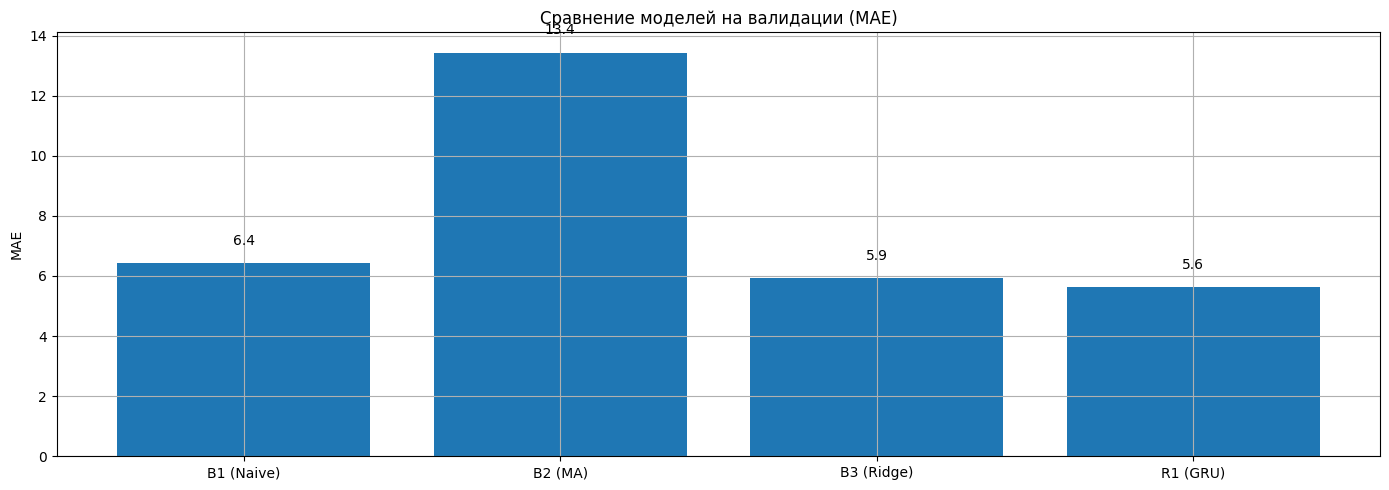

In [17]:
# Сравнение baselines и выбор лучшей модели по validation
# Собираем все результаты валидации в DataFrame
val_results = pd.DataFrame([
    {'model': 'B1 (Naive)', 'MAE': metrics_b1_val['MAE'], 'RMSE': metrics_b1_val['RMSE'], 'MAPE': metrics_b1_val['MAPE']},
    {'model': 'B2 (MA)', 'MAE': metrics_b2_val['MAE'], 'RMSE': metrics_b2_val['RMSE'], 'MAPE': metrics_b2_val['MAPE']},
    {'model': 'B3 (Ridge)', 'MAE': metrics_b3_val['MAE'], 'RMSE': metrics_b3_val['RMSE'], 'MAPE': metrics_b3_val['MAPE']},
    {'model': 'R1 (GRU)', 'MAE': metrics_r1_val['MAE'], 'RMSE': metrics_r1_val['RMSE'], 'MAPE': metrics_r1_val['MAPE']},
])

print("Сравнение моделей на валидации:")
print(val_results.sort_values('MAE'))

# Выбираем лучшую модель по MAE (можно по любому критерию)
best_model_name = val_results.loc[val_results['MAE'].idxmin(), 'model']
best_model_mae = val_results['MAE'].min()
print(f"\nЛучшая модель на валидации: {best_model_name} с MAE = {best_model_mae:.2f}")

# Визуализация сравнения baselines (baselines_compare.png)
fig, ax = plt.subplots()
models = val_results['model']
mae_values = val_results['MAE']
bars = ax.bar(models, mae_values)
ax.set_ylabel('MAE')
ax.set_title('Сравнение моделей на валидации (MAE)')
for bar, val in zip(bars, mae_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/baselines_compare.png', dpi=100)
plt.show()

# 15. Финальная оценка лучшей модели на тесте

ВЫБОР ЛУЧШЕЙ МОДЕЛИ ПО ВАЛИДАЦИИ
Лучшая модель: R1 (GRU)
MAE на валидации: 5.64

Выполняем финальную оценку этой модели на тестовой выборке...

Финальная оценка лучшей модели (R1 - GRU) на тесте:
Test MAE: 6.94
Test RMSE: 8.80
Test MAPE: 4.42%


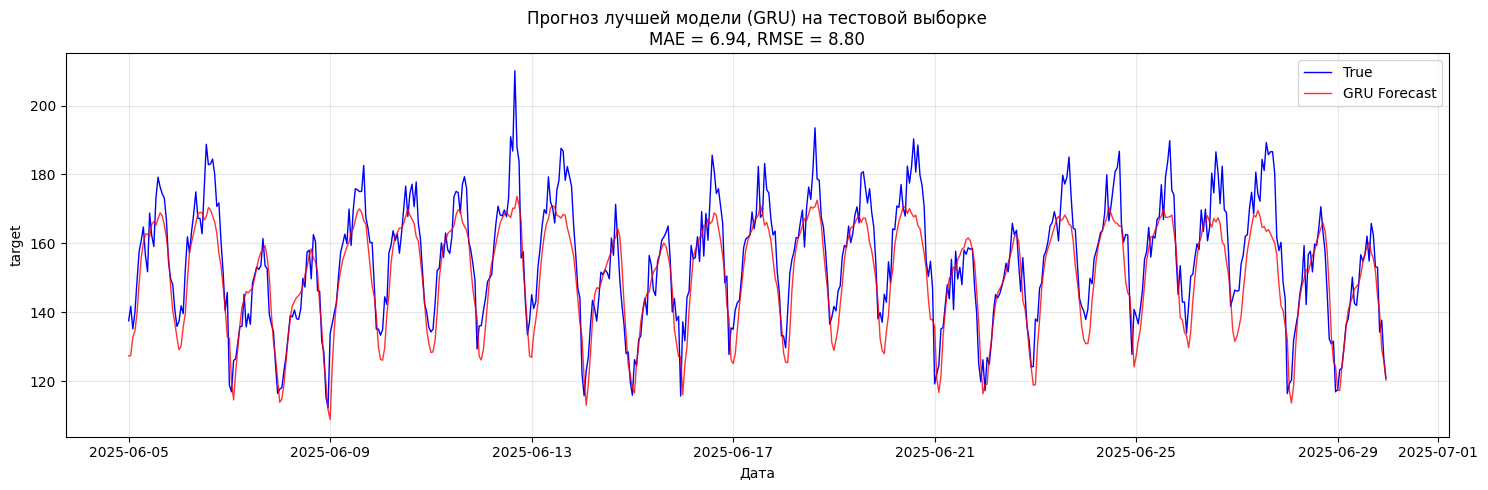

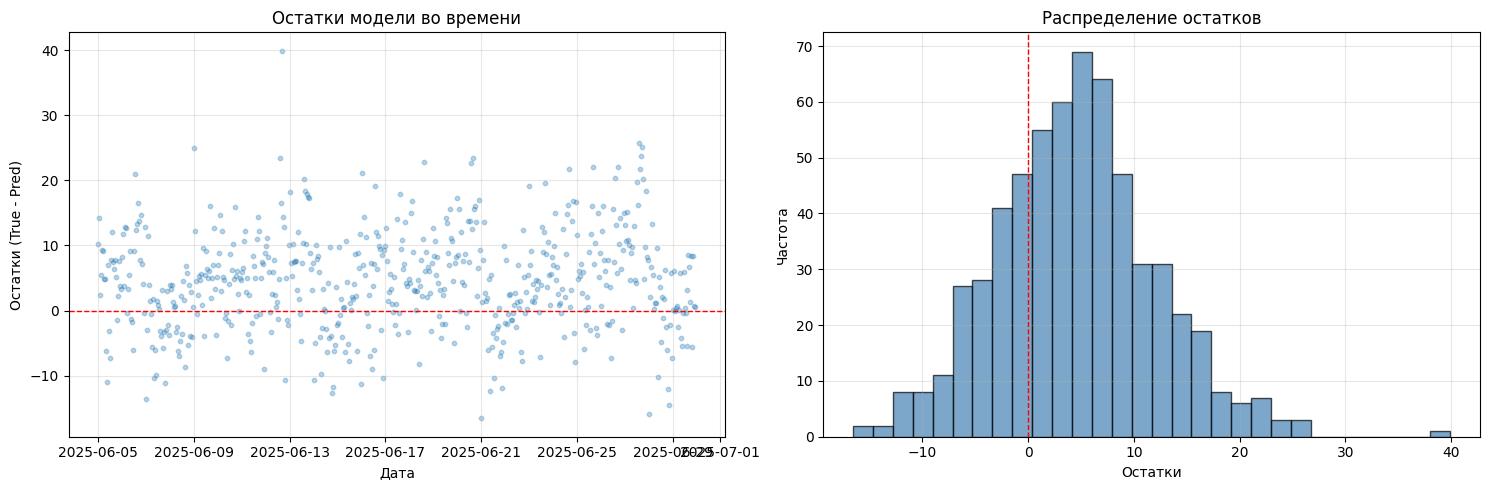


ФИНАЛЬНЫЙ ВЫВОД

Лучшая модель по результатам валидации: R1 (GRU)
Её качество на тестовой выборке:
- MAE:  6.94
- RMSE: 8.80
- MAPE: 4.42%

Графики прогноза и остатков сохранены в artifacts/figures/.



In [19]:
# Финальная оценка на тесте

# Определяем лучшую модель по минимальному MAE на валидации
best_model_by_val = val_results.loc[val_results['MAE'].idxmin(), 'model']
best_mae_val = val_results['MAE'].min()

print("="*60)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ ПО ВАЛИДАЦИИ")
print("="*60)
print(f"Лучшая модель: {best_model_by_val}")
print(f"MAE на валидации: {best_mae_val:.2f}")
print("\nВыполняем финальную оценку этой модели на тестовой выборке...\n")

# В нашем случае лучшая модель - R1 (GRU), что подтверждается результатами

print("Финальная оценка лучшей модели (R1 - GRU) на тесте:")
print(f"Test MAE: {metrics_r1_test['MAE']:.2f}")
print(f"Test RMSE: {metrics_r1_test['RMSE']:.2f}")
print(f"Test MAPE: {metrics_r1_test['MAPE']:.2f}%")

# График прогноза лучшей модели на тесте (best_forecast_test.png)
# Для GRU тестовые предсказания соответствуют сдвигу на window_size
test_dates_gru = test_df['date'].iloc[WINDOW_SIZE:].reset_index(drop=True)
plot_test_df = pd.DataFrame({
    'date': test_dates_gru,
    'true': y_true_gru_test,
    'pred_gru': y_pred_gru_test
})

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_test_df['date'], plot_test_df['true'], label='True', linewidth=1, color='blue')
ax.plot(plot_test_df['date'], plot_test_df['pred_gru'], label='GRU Forecast', linewidth=1, alpha=0.8, color='red')
ax.set_title(f'Прогноз лучшей модели (GRU) на тестовой выборке\nMAE = {metrics_r1_test["MAE"]:.2f}, RMSE = {metrics_r1_test["RMSE"]:.2f}')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/best_forecast_test.png', dpi=100)
plt.show()

# График остатков
residuals = y_true_gru_test - y_pred_gru_test

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График остатков по времени
axes[0].scatter(plot_test_df['date'], residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Остатки модели во времени')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Остатки (True - Pred)')
axes[0].grid(True, alpha=0.3)

# Гистограмма остатков
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Распределение остатков')
axes[1].set_xlabel('Остатки')
axes[1].set_ylabel('Частота')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/residuals_best.png', dpi=100)
plt.show()

print("\n" + "="*60)
print("ФИНАЛЬНЫЙ ВЫВОД")
print("="*60)
print(f"""
Лучшая модель по результатам валидации: {best_model_by_val}
Её качество на тестовой выборке:
- MAE:  {metrics_r1_test['MAE']:.2f}
- RMSE: {metrics_r1_test['RMSE']:.2f}
- MAPE: {metrics_r1_test['MAPE']:.2f}%

Графики прогноза и остатков сохранены в artifacts/figures/.
""")

# 16. Сохранение результатов в runs.csv

In [20]:
# 12. Сохранение артефактов: runs.csv
runs_df = pd.DataFrame(runs_data)
runs_df.to_csv('homeworks/HW12/artifacts/runs.csv', index=False)
print("Файл homeworks/HW12/artifacts/runs.csv сохранен.")
display(runs_df)

Файл homeworks/HW12/artifacts/runs.csv сохранен.


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset,42,70/15/15 temporal,NaN,1,Naive Last,None,None,None,NaN,NaN,6.438501,8.196911,4.391461,6.340958,8.060187,4.146299,Baseline: predict last observed value
1,B2,forecasting,S12-hw-dataset,42,70/15/15 temporal,24.0,1,Moving Average (window=24),None,None,None,NaN,NaN,13.437365,16.227566,9.228935,13.166443,16.150967,8.767827,Baseline: rolling mean with window 24
2,B3,forecasting,S12-hw-dataset,42,70/15/15 temporal,NaN,1,Ridge regression,"lags [1,7,14], rolling(7) mean/std, hour, dayo...",StandardScaler,None (closed form),NaN,NaN,5.937760,7.493246,4.007311,5.650611,7.301630,3.661380,Ridge with alpha=1.0
3,R1,forecasting,S12-hw-dataset,42,70/15/15 temporal,48.0,1,"GRU (hidden=64, layers=2)",Window of last 48 target values,StandardScaler,Adam,0.001,20.0,5.641001,7.235874,3.773186,6.941916,8.802457,4.418559,Best model saved
